 ## Numerical information extraction from image data

For this lab, we are going to use a basic shapes file. You can download it *here*. Once you have the file you should be able to display if with the code below

C:\Users\eamon\AppData\Local\Temp\ipykernel_17556\3080888912.py:16: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(shapes_image)


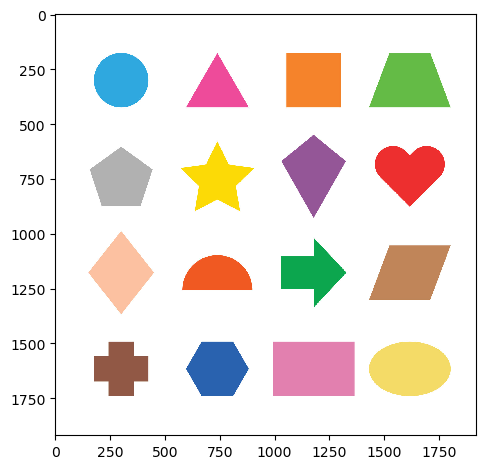

In [44]:
# moved al improts to start as per best practice, so we know what we need in one place
from skimage import io
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage import color
from skimage.filters import threshold_otsu
from skimage import measure
from skimage.filters import gaussian
from skimage.measure import regionprops

from skimage import exposure

# read the image in here also
shapes_image = io.imread('shapes.jpg')
io.imshow(shapes_image)

### Task 1 - Basic Measurements (1.5 marks)

For this task, we will try to extract different pieces of information from each shape. For example, area, perimeter and centroid. To do that, we will need to follow a series of steps.

a) Convert the image to grayscale

C:\Users\eamon\AppData\Local\Temp\ipykernel_17556\2407863185.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(grey_image)


(1920, 1920, 3)
(1920, 1920)


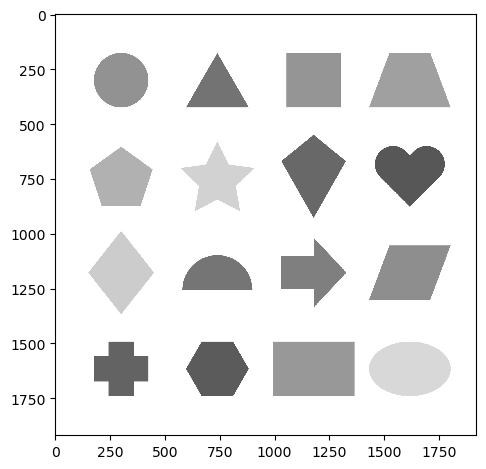

In [45]:
# read in the image
shapes_image = io.imread('shapes.jpg')

# craete grey image object using rgb2grey fucntino from skimage.color 
grey_image = rgb2gray(shapes_image)

# Display the image
io.imshow(grey_image)

print(shapes_image.shape)
print(grey_image.shape)

b) Identify a threshold to separate the images from the background. You can apply the threshold_otsu method, but notice that might not contain all the shapes.

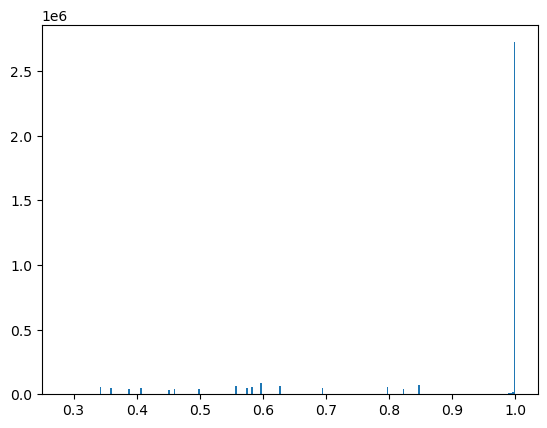

C:\Users\eamon\AppData\Local\Temp\ipykernel_17556\2239615085.py:17: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(binary_otsu)


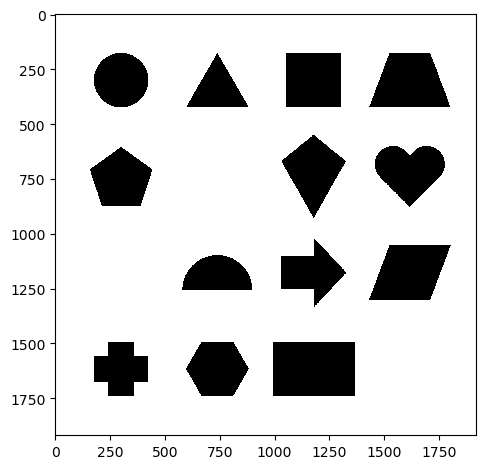

In [46]:
# Import the otsu threshold function- moved the import to  start of file as best practice
# Load a color image
shapes_image = io.imread('shapes.jpg')

# craete grey image object using rgb2grey fucntino from skimage.color 
grey_image = rgb2gray(shapes_image)
plt.hist(grey_image.ravel(), bins=256)
plt.show()

# Make the image grayscale using rgb2gray
image_gray = rgb2gray(shapes_image)
# Obtain the optimal threshold value with otsu
thresh = threshold_otsu(image_gray)
# Apply thresholding to the image
binary_otsu = image_gray > thresh
# Show the image
io.imshow(binary_otsu)





[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]]
[[False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]
 ...
 [False False False ... False False False]
 [False False False ... False False False]
 [False False False ... False False False]]


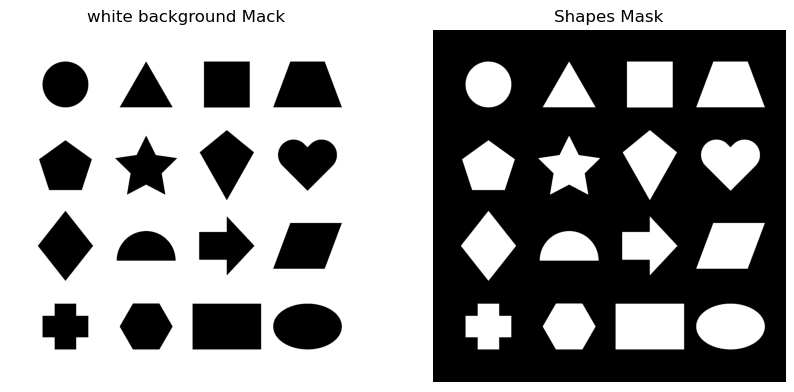

In [ ]:
shapes_image_png = io.imread('shapes.jpg')

# craete grey image object using rgb2grey fucntino from skimage.color 
# tried this with grey scale btu gettgin errors related to no is 3d, grey scale is 2d
# define a white colour mask where all values that are 255, 255, 255
# 255, 255, 255,  = white ad 0,0,0 = black
# axis 2 s 3d, axis = 1 > columns, axis=0 > rows axis  = 2 is to performe the action for all three channels rgb
# this gives us white background and black shapes
# 225 is the optimal value to use here, any value highr get more than 16 regions....
white_col_mask = np.all(shapes_image > 225, axis=2)

# this will give us the reverse of the white mask, so shapes will appear,so we flip it so shapes have a colour
shapes_mask = ~white_col_mask

# just see what was have in the objects
print(white_col_mask)
print(shapes_mask)

#will plot the two masks so we cna see what we have
fg, ax = plt.subplots(1, 2, figsize=(10,5))

ax[0].imshow(white_col_mask, cmap='grey')
ax[0].set_title("white background Mack")
ax[0].axis('off')

ax[1].imshow(shapes_mask, cmap='grey')
ax[1].set_title("Shapes Mask")
ax[1].axis('off')

plt.show()

c) Using the `measure.label` method, create a labelled image. Note: you might need to use the `connectivity` parameter

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


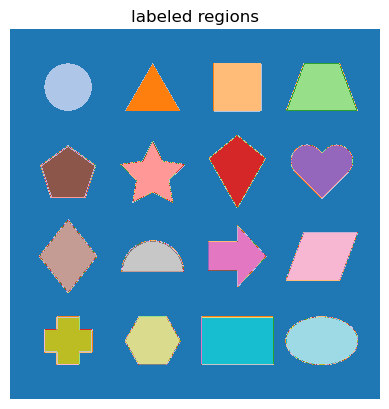

In [59]:
# scikit image > skimage.measure - will help us to define the regions of those shapes
# shoudl ahve 16 labels basically
# https://scikit-image.org/docs/0.25.x/api/skimage.measure.html#skimage.measure.label
# label connected regions of an integer array
# connectivity=None, get an error, use a value of 2?? will make sure neighbours have same colour
# that wll give us label for 16 regions  as have 16 shapes in that image

#apply the label functin to our shapes masked image
labels = measure.label(shapes_mask, connectivity=2)
label_values = np.unique(labels)
# make sure label values are as expect
print(label_values) 
# style of pltting can make it harder to see some shapes, gradients etc viridinis for eg and nipy...
plt.imshow(labels, cmap='tab20')
plt.title("labeled regions")
plt.axis('off')
plt.show()



d) Use the `measure.regionprops` passing the labelled image. This method will return a iterable object, with information about each labelled region in the image. Check what are the attributes of each object. Print area, perimeter and centroid.

[<skimage.measure._regionprops.RegionProperties object at 0x00000185278C4980>, <skimage.measure._regionprops.RegionProperties object at 0x0000018527541A60>, <skimage.measure._regionprops.RegionProperties object at 0x00000185274C38F0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185250F6120>, <skimage.measure._regionprops.RegionProperties object at 0x000001852A8E2810>, <skimage.measure._regionprops.RegionProperties object at 0x0000018527512240>, <skimage.measure._regionprops.RegionProperties object at 0x0000018527512D20>, <skimage.measure._regionprops.RegionProperties object at 0x0000018527575FD0>, <skimage.measure._regionprops.RegionProperties object at 0x000001852A8FFCB0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185272B7170>, <skimage.measure._regionprops.RegionProperties object at 0x00000185276F5940>, <skimage.measure._regionprops.RegionProperties object at 0x00000185276F4C80>, <skimage.measure._regionprops.RegionProperties object at 0x0000

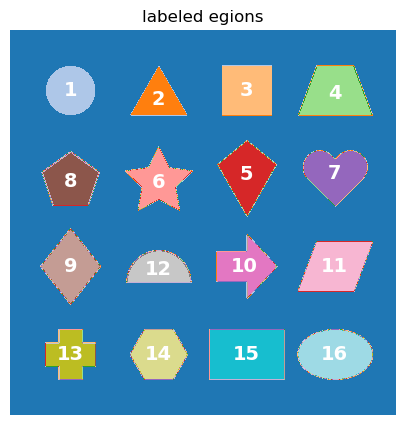

====== Region  1  =======
Area =  48860.0
Perimeter =  824.3645737753168
Centroid =  (301.20261972984036, 301.2051780597626)

====== Region  2  =======
Area =  35950.0
Perimeter =  902.1219330881976
Centroid =  (342.3432545201669, 740.0647844228095)

====== Region  3  =======
Area =  62250.0
Perimeter =  995.8994949366117
Centroid =  (301.49606425702814, 1178.9920803212851)

====== Region  4  =======
Area =  69805.0
Perimeter =  1131.8721497261417
Centroid =  (314.8251271398897, 1617.8311009240026)

====== Region  5  =======
Area =  56385.0
Perimeter =  1035.1900423072327
Centroid =  (716.9512813691584, 1178.940977210251)

====== Region  6  =======
Area =  46490.0
Perimeter =  1241.35447250755
Centroid =  (756.9349752634976, 740.081759518176)

====== Region  7  =======
Area =  58215.0
Perimeter =  985.6925676241744
Centroid =  (713.1883019840247, 1617.831538263334)

====== Region  8  =======
Area =  53756.0
Perimeter =  927.477272147525
Centroid =  (754.3476449140561, 301.2147667237145

In [ ]:
# using the labels from above
# goign to knwo area of that shapes_image can see the parameter if we want and the centroids so where it is locate dint he region
# https://scikit-image.org/docs/0.25.x/api/skimage.measure.html#skimage.measure.regionprops

# had to plot these a bti earlier to fix and issue with having 20 + regions , so needed to see where they were actually occuring 
# to help troubleshoot the issue
regions = measure.regionprops(labels)
print(regions)

fig, ax = plt.subplots(figsize=(10, 5))
plt.imshow(labels, cmap='tab20')
plt.title("labeled egions")
plt.axis('off')

# loop through regions to get cemtroid values then plot them
for r in regions:
    y, x = r.centroid
    ax.text(x, y, str(r.label), color='white', fontsize=14, weight='bold', ha='center', va='center')

plt.show()
# wil print otu values aswell so can see the objects values
for prop in regions:
        print(f"====== Region  {prop.label}  =======" )
        print(f"Area =  {prop.area}")
        print(f"Perimeter =  {prop.perimeter}")
        print(f"Centroid =  {prop.centroid}")
        print()
        

e) The label function won't return the labels in any specific order. To identify which shape corresponds to each region, use the centroid value again, and add the image number over the shape. A partial solution is given below.

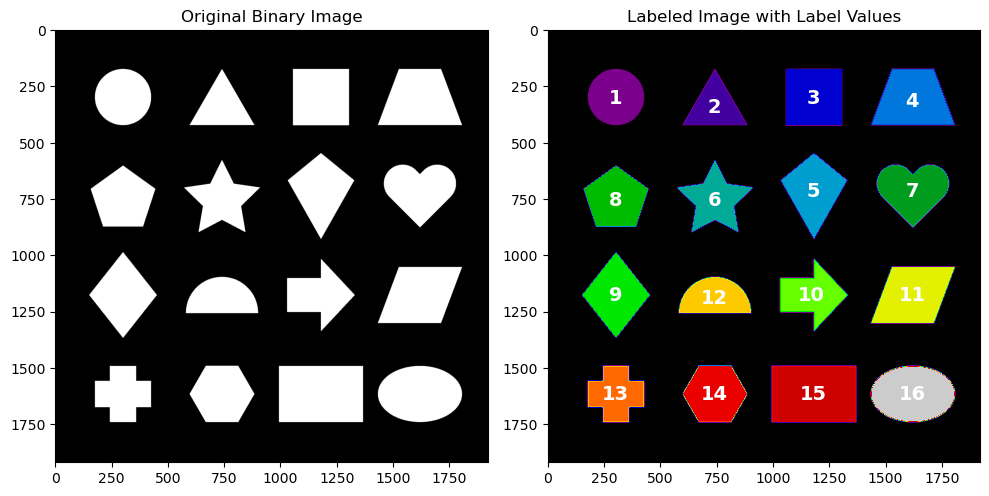

In [ ]:
# we wl get 1, 5, 10. 7. 3 so to knwo which oen is which this exrcise will ask to just plot the image btu add
# label to the graph with number over the shapes_image/ add the label of the region

# Visualize the original binary image and the labeled image with label values
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Original binary image
axes[0].imshow(shapes_mask, cmap='gray')
axes[0].set_title('Original Binary Image')

# Labeled image with label values overlaid
axes[1].imshow(labels, cmap='nipy_spectral')

# Annotate each labeled region with its label value
for region in measure.regionprops(labels):
   
    # Get x, y values of the region centroid
    y, x = region.centroid
    
    # Using the text method for axes, add the region.label to axes[1] in the centroid coordinates 
    axes[1].text(x, y, str(region.label), color='white', fontsize=14, weight='bold', ha='center', va="center")


axes[1].set_title('Labeled Image with Label Values')

plt.tight_layout()
plt.show()

### Task 2 - Intensity Statistics (3 marks)

The mean intensity value of a single color channel provides information about the average brightness or intensity of that specific color within the image or a region of that image. The mean intensity value for a specific channel gives an average measure of the brightness of that color across the entire image. Let's have a look at intensity values for the previous shapes figure.

**a)** Note that in the original figure shapes have different colors. We are going to use `measure.regionprops` again to compute the mean and standard deviation intensity of pixel values for each region. You will need to do that for each color channel.

Hints: Use the `intensity_image` parameter of `regionprops` passing a image with a single color channel. To get a image with a single color channel you can slice the image for all rows and coluns, but a single color channel. Next, You can use the numpy methods `mean` and `std` to get the mean and std from the `intensity_image` attribute returned by regionprops object.

In [51]:
# play a bti wiht the wcolours
# mean of mean
# std dev of pixel valeus for each image
# compare these with mean intensity of the shapes_imagemean avleu for reversedmeand valeu for bleu mean avleuj for green

# our shapes_image is 3D, we choose the colour with the last valeu
red_channel = shapes_image[:, :, 0]  
green_channel = shapes_image[:, :, 1]
blue_channel = shapes_image[:, :, 2]
print(red_channel)

# get the region properties
regprop_red = measure.regionprops(labels, intensity_image=red_channel)
regprop_green = measure.regionprops(labels, intensity_image=green_channel)
regprop_blue = measure.regionprops(labels, intensity_image=blue_channel)
print(regprop_red)

# creating emoty list to use in loop to store values to plot them later
mean_red_list = []
mean_green_list = []
mean_blue_list = []

# will loop through each region and calculate the mean colour value and then the std deviation for each value
for i in range(len(regprop_red)):
    # these are list objects, so need to sslect the items through the loop
    prop_red = regprop_red [i]
    prop_green = regprop_green [i]
    prop_blue = regprop_blue[i]
    
    # the mean red, green, blue channel values, the cloer the number to 255 the strongr the red colour
    mean_red =  prop_red.intensity_image.mean()
    mean_green =  prop_green.intensity_image.mean()
    mean_blue =  prop_blue.intensity_image.mean()
    
    # the standard deviation, the spread of colour values form - to 255, if low number means all similar colour, if its higher umebr means theres a spread of colours, no one colour is dominant
    std_dev_red = prop_red.intensity_image.std()
    std_dev_green = prop_green.intensity_image.std()
    std_dev_blue = prop_blue.intensity_image.std()
    
    ## adding list cteration part here for next task part to plto the values
    mean_red_list.append(mean_red)
    mean_green_list.append(mean_green)
    mean_blue_list.append(mean_blue)
    
    # they all ahve the same label, 1, 2, 4 etc, so will just call out red here and it will apply to green and blue also
    print(f"====== Region  {prop_red.label}  === Mean and Std Dev ====" )
    print(f" Mean  Red =   {mean_red} ") 
    print(f" Mean  Green =   {mean_green}")
    print(f" Mean Blue  = {mean_blue}")
    print(f" Std Dev  Red =   {std_dev_red} ") 
    print(f" Std Dev  Green =   {std_dev_green}")
    print(f" Std dDv Blue  = {std_dev_blue}")
    print()
    
print(f"redlist = {mean_red_list}")
print(f"red std dev = {std_dev_red}")

[[255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 ...
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]
 [255 255 255 ... 255 255 255]]
[<skimage.measure._regionprops.RegionProperties object at 0x00000185250F7E30>, <skimage.measure._regionprops.RegionProperties object at 0x00000185244A5BB0>, <skimage.measure._regionprops.RegionProperties object at 0x0000018527B41FA0>, <skimage.measure._regionprops.RegionProperties object at 0x000001852A7B3C80>, <skimage.measure._regionprops.RegionProperties object at 0x000001852A7B0EC0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185254903B0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185254939B0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185254933E0>, <skimage.measure._regionprops.RegionProperties object at 0x0000018525491F70>, <skimage.measure._regionprops.RegionProperties object at 0x00000185254931D0>, <skimage.measure._regionpro

**b)** Plot three bar charts (one for each color channel) comparing the mean intensity of all shapes. You can create a list with all the mean intensity values to use in the plot.



[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]


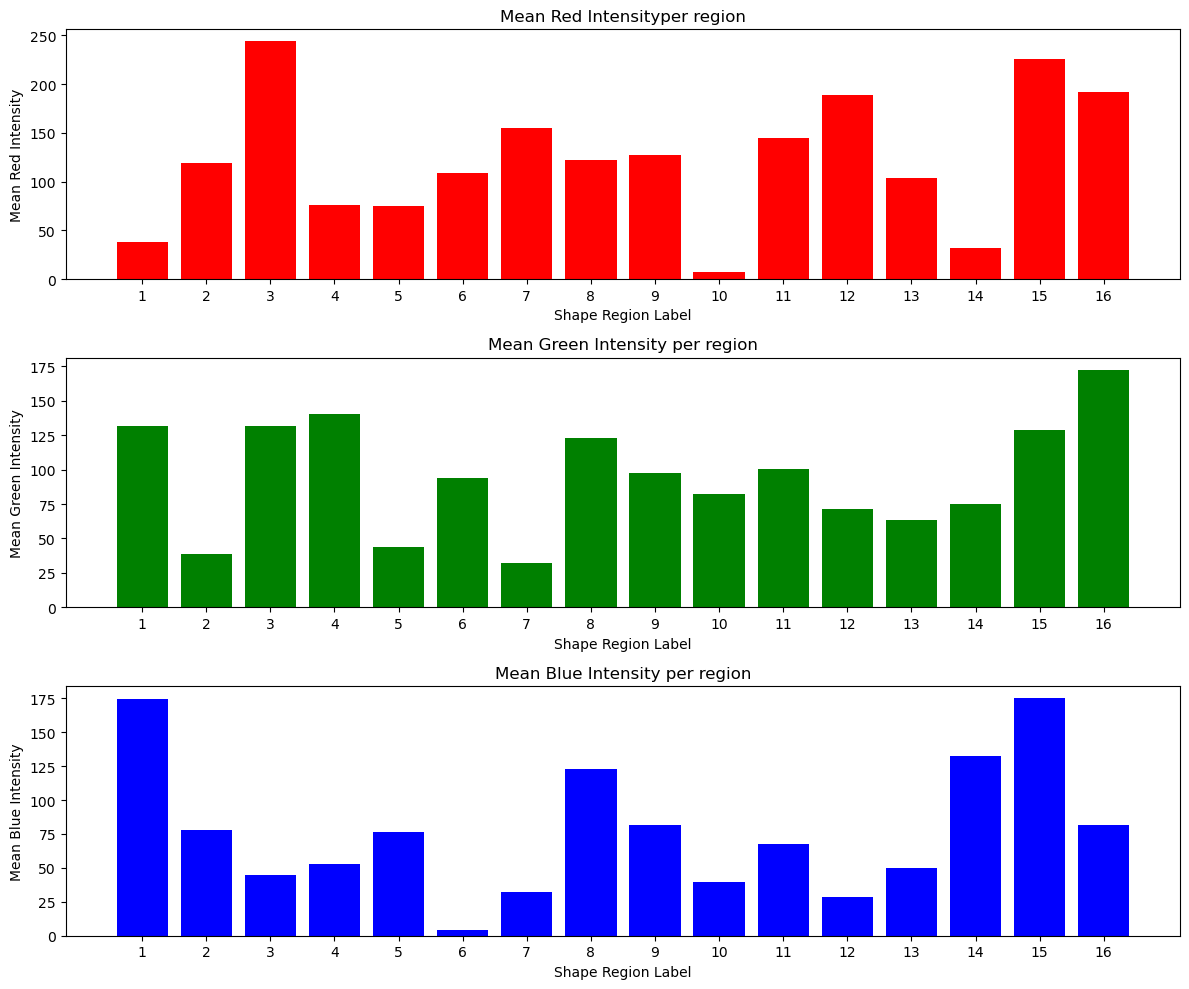

In [52]:
# mean of mean
# std dev of pixel valeus for each image
# compare these with mean intensity of the shapes_imagemean avleu for reversedmeand valeu for bleu mean avleuj for green

# created the mean list in the earlier task as had the lop runnign there and was mroe efficient to create the mean colour list in that loop

# x-axis = region numbers (1 to number of shapes)
regions = np.arange(1, len(mean_red_list) + 1)
print(regions)

plt.figure(figsize=(12, 10))

# ---- Red Channel ----
plt.subplot(3, 1, 1)
plt.bar(regions, mean_red_list, color='red')
plt.title("Mean Red Intensityper region")
plt.xlabel("Shape Region Label")
plt.ylabel("Mean Red Intensity")
plt.xticks(regions)

# ---- Green Channel ----
plt.subplot(3, 1, 2)
plt.bar(regions, mean_green_list, color='green')
plt.title("Mean Green Intensity per region")
plt.xlabel("Shape Region Label")
plt.ylabel("Mean Green Intensity")
plt.xticks(regions)

# ---- Blue Channel ----
plt.subplot(3, 1, 3)
plt.bar(regions, mean_blue_list, color='blue')
plt.title("Mean Blue Intensity per region")
plt.xlabel("Shape Region Label")
plt.ylabel("Mean Blue Intensity")
plt.xticks(regions)

plt.tight_layout()
plt.show()


### Task 3 - Histogram Analysis (4.5 marks)

Another way to evaluate pixel value information is by histograms.

a) Plot the histogram of pixel values in the red channel for the shape images. We can use [exposure.histogram](https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.histogram) method to extract the histogram array and bin centers of each histogram bin. 

[     40      23      25      27      50      67     225     127     128
     426     755     517   41084     476     309     415     238     246
     236      69      40      35      21      18      10       9      11
       9       5      10      15      17      29      39      70      95
     114     345     345     310     510   49990     846     472     473
     435     468   44906     396     294     239     196     139     100
      61      49      38      26      18      25      22      20      17
      15      23      22      24      16      16      17      13      20
      13     149      13      13       9      19      12      15      13
      19      13      17      22      14      13      17      15      14
      18      18      24      48      64      85     121     177     261
     644   65536     657     571     162     122      91      72      46
      39      44      37      29      32      21      25     170      20
      29      22      14      10      14      21   

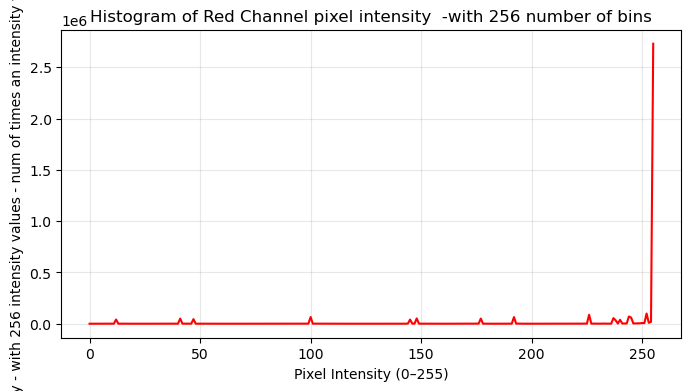

In [53]:
# # https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.histogram

# got ecample from here also > https://stackoverflow.com/questions/44166763/bins-must-increase-monotonically  

# # we defined this earlier, so calling again here so awrae of what it is
red_channel = shapes_image[:, :, 0]  



# # Extract the red channel from the RGB shapes image
# red_channel = shapes_image[:, :, 0]

# Get histogram data using skimage.exposure.histogram
# runngin exposure.histogram on the red channel array will get us two values, 
# the intensity values of each pixel, how manhy ahve zero pixels, how many pixels ahve 1, how many pixels ahve 2 etc
# our image is 0 to 255 values > we get an integer value for each pixel intensity value
# every intensity integer gets its own bin value in a oen to one mapping
# for us here there are always 256 bins >> does nto guess how many bins to use
# its a one to one mapping of intensity to bin
# exposure.histogram neve does this, it always keeps 1 bin per unique integer value
hist, bins = exposure.histogram(red_channel)
# view the output, can see 2D arrays first on intensity values from the image
# 2nd bin values mapping to the intensity values
# for non integer images i.e. floats, logs etc bin values are ranges, not single integer values
print(hist)
print(bins)

# take the two outputs from our exposure.histogram function and plot them
plt.figure(figsize=(8, 4))
plt.plot(bins, hist, color='red')

plt.title(f"Histogram of Red Channel pixel intensity  -with {len(bins)} number of bins")
plt.xlabel("Pixel Intensity (0–255)")
plt.ylabel(f"Frequency - with {len(hist)} intensity values - num of times an intensity value occurs")
plt.grid(alpha=0.3)
plt.show()

b) After analysing the histograms in a), modify the original shapes image and keep only the shapes with high frequency of strong red values (pixels from 100 to 255 with higher frequency in the red color channel).

You can check if the sum of frequencies in the histogram from index 0 up to 100 is lower than the sum of frequencies for indexes from 101 until 255. If they are, extract the bounding box of the region, with the [bbox](https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops) property of the region, and set all pixel values in the region to 255 (in all color channels).

Show the original image without the shapes with low frequency of strong red values.

Hint: the histogram might not have indexes up to 255. 

[<skimage.measure._regionprops.RegionProperties object at 0x0000018525443290>, <skimage.measure._regionprops.RegionProperties object at 0x00000185253813D0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185247C0C20>, <skimage.measure._regionprops.RegionProperties object at 0x000001852A984BC0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185250DC6E0>, <skimage.measure._regionprops.RegionProperties object at 0x00000185250DC050>, <skimage.measure._regionprops.RegionProperties object at 0x00000185250DE870>, <skimage.measure._regionprops.RegionProperties object at 0x00000185250DFE90>, <skimage.measure._regionprops.RegionProperties object at 0x000001852727E060>, <skimage.measure._regionprops.RegionProperties object at 0x00000185299F7170>, <skimage.measure._regionprops.RegionProperties object at 0x00000185299F4230>, <skimage.measure._regionprops.RegionProperties object at 0x000001852549F680>, <skimage.measure._regionprops.RegionProperties object at 0x0000

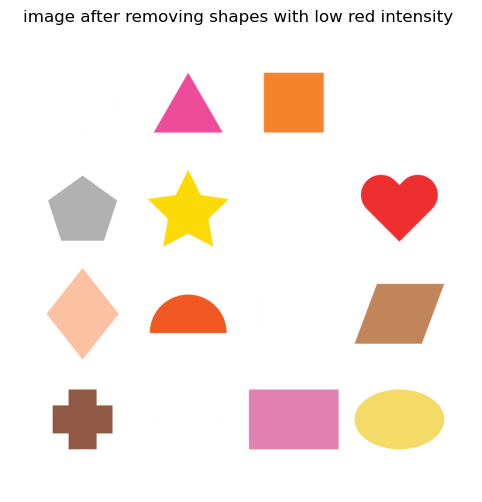

In [54]:
# # # will grab image again so knwo where we are and assign anew variable name to it to keep us separated fomr previosu work
shapes_image_task3 = shapes_image

# will also get the regions data objects again to be clean
# the labels object was the kage wiht the regions assigned
regions_task3b = measure.regionprops(labels)
# just have a lok to make sure its what we expcect to get
print(regions_task3b)
#w e calculated the mean red values from before mean_red_list, so we will use that ot get strong reds
print(mean_red_list)

# we'll us e afoor loop to loop throuhg the regions and the mean red values for each region
for region, red_mean in zip(regions_task3b, mean_red_list):
    # set our cut off point as per instructions in task
    # and if the value for mean red is < or -= to 100 then change to white background ie.. remove the region
    if red_mean <=100:
        # we'll use bounding box to put a box around the shape, as asked int he instructions
        # https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops also
        # https://scikit-image.org/docs/0.25.x/auto_examples/segmentation/plot_label.html 
        min_row, min_col, max_row, max_col=region.bbox
        # change the bounding box region to white  i.e. 255, 255, 255
        shapes_image_task3[min_row:max_row, min_col:max_col] = [255,255,255]

    
    
plt.figure(figsize=(8,6))
plt.imshow(shapes_image_task3)
plt.title("image after removing shapes with low red intensity ")
plt.axis('off')
plt.show()
     

c) Filtering shapes by the frequency of strong red values, is just way one of analysing the image. This should allow to create other custom metrics and identify reagions of interest in an image. For example, the ratio of the area of a region to its bounding box area can provide insights into how "compact" or "spread out" each labeled region is. As an optional task you can play with the previous exercise and attempt any custom metric of interest.

====== Region  1  ===compactness ratio and perimeter====
 Compactness ratio  = 0.78176 
Perimeter is = 824.3645737753168
====== Region  2  ===compactness ratio and perimeter====
 Compactness ratio  = 0.5010452961672474 
Perimeter is = 902.1219330881976
====== Region  3  ===compactness ratio and perimeter====
 Compactness ratio  = 0.996 
Perimeter is = 995.8994949366117
====== Region  4  ===compactness ratio and perimeter====
 Compactness ratio  = 0.7485790884718498 
Perimeter is = 1131.8721497261417
====== Region  5  ===compactness ratio and perimeter====
 Compactness ratio  = 0.5016682236754304 
Perimeter is = 1035.1900423072327
====== Region  6  ===compactness ratio and perimeter====
 Compactness ratio  = 0.43110163204747776 
Perimeter is = 1241.35447250755
====== Region  7  ===compactness ratio and perimeter====
 Compactness ratio  = 0.6543952338129496 
Perimeter is = 985.6925676241744
====== Region  8  ===compactness ratio and perimeter====
 Compactness ratio  = 0.6911554829834012 

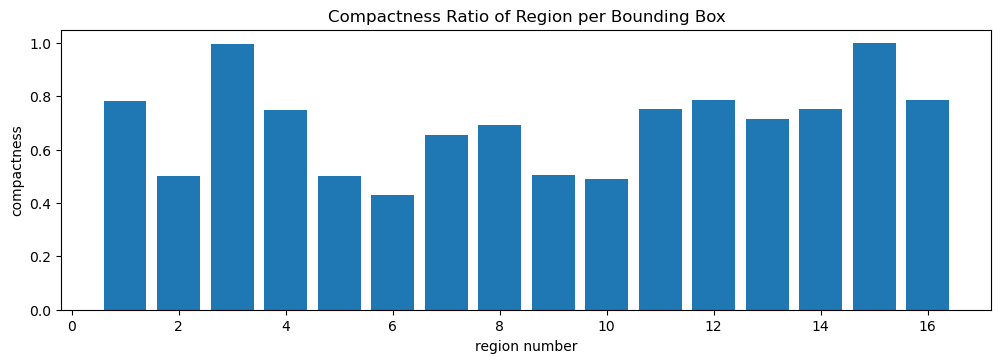

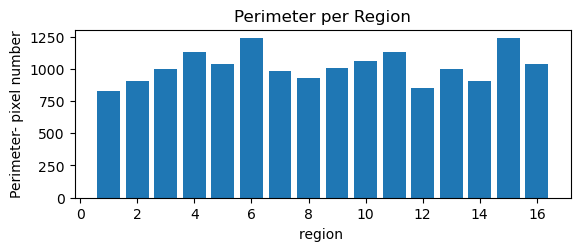

In [55]:
# will do ratio of an area to its bounding box to see compactness as a start anyway
# and then also obtain the operimeter value for each region
# https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops

#getting new variable for region props just to keep us clean and separated from previous cell
regions_task3c = measure.regionprops(labels)

# craete  empty lists to hold regin number, compactness ratio and perimeter values so cna plot from them later
region_num_list = []
compactness_vals_list = []
perimeter_vals_list = []

# calc ulate the ratio of bounding box area to shape area - get a ratio
# clcuate the perimieter for each region
for region in regions_task3c:
    # get bounding box for al regions
    min_row, min_col, max_row, max_col=region.bbox
    box_area = (max_row - min_row) * (max_col - min_col)
    # calc rati value using the area property from regino props and divide but boundung box area
    compactness_value = region.area / box_area
    
    # perimeter
    perim_value  = region.perimeter
    
    # append to the lists for each prop value
    region_num_list.append(region.label)
    compactness_vals_list.append(compactness_value)
    perimeter_vals_list.append(perim_value)

    print(f"====== Region  {region.label}  ===compactness ratio and perimeter====" )
    print(f" Compactness ratio  = {compactness_value} ")
    print(f"Perimeter is = {perim_value}")
    
    
    
plt.figure(figsize=(12, 8))

plt.subplot(2,1,1)
plt.bar(region_num_list, compactness_vals_list)
plt.title("Compactness Ratio of Region per Bounding Box")
plt.xlabel('region number')
plt.ylabel('compactness')
plt.show()

plt.subplot(2,1,1)
plt.bar(region_num_list, perimeter_vals_list)
plt.title("Perimeter per Region")
plt.xlabel('region ')
plt.ylabel('Perimeter- pixel number')


plt.show()


### Task 4 - Report (1 marks)

Summarise the tasks you completed when working with the image file. Highlight any challenges faced and how you resolved them. Were there any skills or concepts more challenging and rewarding to learn in this lab?
